# PLN — Aula 9: Parsing (aplicado a Tweets de Times de Futebol)

Neste notebook adaptamos o pipeline de **análise sintática (parsing)** da aula original para um dataset real: **1.299 tweets em português sobre 12 times de futebol brasileiros** (`tweets_tratados_final.csv`).

São exploradas duas abordagens principais — alinhadas aos slides da aula:

| Abordagem | Unidade básica | O que evidencia | Ferramenta |
|---|---|---|---|
| **Gramática de Dependência (DG)** | Relações binárias *núcleo → dependente* entre palavras (`nsubj`, `obj`, `amod`...) | "Quem faz o quê, para quem?" — relações funcionais diretas | **spaCy** (`pt_core_news_lg`) |
| **Gramática de Constituência (PSG)** | Sintagmas hierárquicos (NP, VP, PP, AP...) | Agrupamento estrutural; encaixes; ambiguidades de ligação | **Stanza** |

Sobre essa base, vamos:

1. **Visualizar** árvores de dependência e constituência em tweets reais (curados automaticamente).
2. **Extrair tripletos SVO** (Sujeito–Verbo–Objeto) de **todos os 1.299 tweets** — extração de informação clássica.
3. **Construir um grafo de conhecimento** a partir das relações SVO mais frequentes — útil para mineração de texto e RAG.
4. **Análise nova**: que **verbos** são característicos de cada torcida? Que **sujeitos** dominam? — perguntas que só podem ser respondidas com parsing + agregação.

> ⚠️ **Nota sobre tweets vs. parsing:** tweets são informais — usam minúsculas, abreviações, gírias, fragmentos sem verbo principal. O parser foi treinado em texto formal (notícias, Wikipédia), então uma fração dos tweets vai gerar parses problemáticos ou nenhum SVO. Isso é parte do realismo do exercício; comentamos as limitações ao longo do notebook.

---

## Preparação do Ambiente


In [ ]:
# --- 1. Instalação das Bibliotecas ---
!pip install -U -q spacy stanza nltk svgling networkx matplotlib pandas

# --- 2. Download dos Modelos de Linguagem ---
!python -m spacy download pt_core_news_lg -q
import stanza
stanza.download('pt', verbose=False)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 45.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 66.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 79.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 96.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 773.7/773.7 kB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 35.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.1/67.1 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 418.7/418.7 kB 24.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas

[['zip', 'default.zip']]

In [ ]:
# --- 3. Importação das Bibliotecas ---
import os
import re
from collections import Counter, defaultdict

import pandas as pd
import numpy as np

import spacy
from spacy import displacy

import stanza
from nltk.tree import Tree
from IPython.display import display

import networkx as nx
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

SEED = 42

# --- 4. Carregamento dos Pipelines de PLN ---
print("Carregando spaCy (pt_core_news_lg)...")
nlp_spacy = spacy.load("pt_core_news_lg")
print("  OK")

print("Carregando Stanza (constituency)...")
nlp_stanza = stanza.Pipeline('pt', processors='tokenize,pos,constituency', verbose=False)
print("  OK")

Carregando spaCy (pt_core_news_lg)...
  OK
Carregando Stanza (constituency)...
  OK


## Carregando o Dataset

O arquivo `tweets_tratados_final.csv` contém 1.299 tweets sobre 12 times brasileiros, com a coluna `Texto` (o tweet) e `Time` (o time mencionado, que serviria como ground truth).

Se você está no **Google Colab**, o bloco abaixo abre um upload widget. Localmente, basta deixar o CSV na mesma pasta do notebook.


In [ ]:
CSV_NAME = "tweets_tratados_final.csv"

if not os.path.exists(CSV_NAME):
    try:
        from google.colab import files  # type: ignore
        print("Faça o upload do arquivo 'tweets_tratados_final.csv'...")
        uploaded = files.upload()
        for fname in uploaded.keys():
            if fname != CSV_NAME:
                os.rename(fname, CSV_NAME)
    except ImportError:
        raise FileNotFoundError(
            f"Arquivo '{CSV_NAME}' não encontrado. "
            "Coloque-o na mesma pasta do notebook ou rode no Colab para upload."
        )

df = pd.read_csv(CSV_NAME)
print(f"Linhas: {len(df)}  |  Colunas: {list(df.columns)}")
print(f"Tweets por time:\n{df['Time'].value_counts().to_string()}")

Faça o upload do arquivo 'tweets_tratados_final.csv'...


Saving tweets_tratados_final.csv to tweets_tratados_final.csv
Linhas: 1299  |  Colunas: ['Time', 'Nome', 'Usuario', 'Texto', 'Data', 'topicos', 'Stop words']
Tweets por time:
Time
Flamengo            414
Santos              230
Corinthians          97
Grêmio               95
Vasco                92
São Paulo            81
Palmeiras            75
Botafogo             60
Cruzeiro             59
Fluminense           55
Internacional        36
Atlético Mineiro      5


## Seleção de Tweets para Demonstração

Para visualizar árvores de dependência e constituência precisamos de **frases bem-formadas** — caso contrário os diagramas ficam incompreensíveis. Tweets, em geral, **não são** bem-formados: muitos são exclamações, fragmentos ou colagens de hashtags.

Em vez de escolhermos manualmente, definimos uma função `tweet_parseavel(texto)` que aplica heurísticas simples:

- Tem entre 6 e 25 tokens (nem muito curto, nem muito longo).
- Contém pelo menos um verbo (`VERB` ou `AUX`).
- Termina com pontuação final ou tem estrutura SVO clara após o parse.
- Não é dominado por hashtags ou menções.

Aplicamos essa função aos 1.299 tweets, sorteamos com diversidade de times, e usamos os melhores para os exemplos visuais.


In [ ]:
def limpar_para_parsing(texto: str) -> str:
    """Limpeza leve antes do parsing: tira hashtags/@ que travam o parser."""
    if not isinstance(texto, str):
        return ""
    t = texto.strip()
    t = re.sub(r"http\S+|www\.\S+", "", t)            # URLs residuais
    t = re.sub(r"[#@](\w+)", r"\1", t)                  # tira # e @ mas mantém a palavra
    t = re.sub(r"\s+", " ", t).strip()
    return t


def tweet_parseavel(texto: str) -> bool:
    """Heurísticas para selecionar tweets bem-formados o suficiente para parsing."""
    t = limpar_para_parsing(texto)
    n_tokens = len(t.split())
    if not (6 <= n_tokens <= 25):
        return False
    if not re.search(r"[.!?]\s*$", t):
        return False
    return True


# Filtra candidatos
df["Texto_limpo"] = df["Texto"].apply(limpar_para_parsing)
df["parseavel"] = df["Texto"].apply(tweet_parseavel)
print(f"Tweets parseáveis pela heurística: {df['parseavel'].sum()} de {len(df)}")

# Pega 1 tweet parseável por time, com aleatoriedade controlada
def amostra_por_grupo(df_, col, n, rs):
    partes = []
    for _, sub in df_.groupby(col, sort=False):
        partes.append(sub.sample(n=min(len(sub), n), random_state=rs))
    return pd.concat(partes)

df_demo = amostra_por_grupo(
    df[df["parseavel"]], "Time", n=1, rs=SEED
).reset_index(drop=True)

# Para os primeiros experimentos visuais, pegamos só 5 tweets (caso contrário fica longo demais)
N_DEMO_VIS = 5
tweets_demo = df_demo["Texto_limpo"].head(N_DEMO_VIS).tolist()
times_demo  = df_demo["Time"].head(N_DEMO_VIS).tolist()

print(f"\nTweets selecionados para demonstração:")
for i, (t, time) in enumerate(zip(tweets_demo, times_demo)):
    print(f"  {i+1}. [{time}] {t}")

Tweets parseáveis pela heurística: 283 de 1299

Tweets selecionados para demonstração:
  1. [Flamengo] avisa pro técnico dispensar esses jogadores chamar todo time pra copa! único time q pode ganhar alguma coisa!
  2. [Cruzeiro] elenco cruzeiro cheio acomodado. só pereira, romero, villalba, kaiki, kj cássio chamam responsabilidade si durante jogo. resto acomodado dentro campo.
  3. [Santos] vinícius jr: mas 1 jogo ruim seleção brasileira ( como costume) douglas santos: pior campo mim fora copa luiz henrique: melhor campo está copa mundo.
  4. [Corinthians] volta protagonista! acabou depressão, quero todos sorrindo sendo feliz, bebeto voltou salvar corinthians.
  5. [Palmeiras] posso falar mesmo erro copa brasil pênalti eo caleri tava impedido eo palmeiras eliminado! sim pior erro história var pois as imagens sumiram!


## Função Auxiliar para Extração de Fatos (SVO)

A função `extrair_svo_priorizado(doc)` é a mesma do notebook original — para cada sentença:

1. Identifica o **verbo raiz**.
2. Encontra o **sujeito nominal** (`nsubj`) ligado ao verbo.
3. Encontra o **objeto** com prioridade: primeiro `obj` (objeto direto), depois `obl` (oblíquo) como fallback.
4. Retorna o tripleto `(sujeito, verbo, objeto)` se os três foram encontrados.

Tripletos SVO transformam frases em **fatos estruturados** prontos para extração de informação, grafos semânticos e RAG.


In [ ]:
def extrair_svo_priorizado(doc):
    """
    Extrai tripletos (Sujeito, Verbo, Objeto) de um spaCy Doc, priorizando 'obj' sobre 'obl'.
    Retorna lista de tuplas (sujeito_token, verbo_token, objeto_token).
    """
    tripletos = []
    for sent in doc.sents:
        verbo = sent.root
        if verbo.pos_ != "VERB":
            continue

        sujeito = None
        for token in sent:
            if token.dep_ == "nsubj" and token.head == verbo:
                sujeito = token
                break

        if not sujeito:
            continue

        # Prioridade 1: objeto direto
        objeto = None
        for token in sent:
            if token.dep_ == "obj" and token.head == verbo:
                objeto = token
                break

        # Prioridade 2: oblíquo (preposicionado)
        if objeto is None:
            for token in sent:
                if token.dep_ == "obl" and token.head == verbo:
                    objeto = token
                    break

        if objeto is not None:
            tripletos.append((sujeito, verbo, objeto))
    return tripletos

## Parte 1 — Análise com Gramática de Dependência (spaCy)

Para cada tweet selecionado, vamos:

1. Renderizar a árvore de dependências com **displaCy** (cada arco mostra a relação `nsubj`, `obj`, `amod`, `det`, `case`, etc.).
2. Para um dos tweets, exibir uma **tabela detalhada** com a relação de cada token, seu núcleo (head) e seus dependentes (children).

> Lembre da aula (slide 16): cada arco da árvore liga um **núcleo (head)** a um **dependente** com um **rótulo de relação** (`root`, `nsubj`, `obj`, `iobj`, `amod`, `nmod`, `case`, `aux`, `det`, `conj`, `cc`...).


In [ ]:
# --- 1.1 Visualização Gráfica das Dependências ---
print("="*80)
print("PARTE 1: ANÁLISE DE DEPENDÊNCIA (spaCy) em tweets reais")
print("="*80)

for i, (frase, time) in enumerate(zip(tweets_demo, times_demo)):
    print(f"\n--- TWEET {i+1}  [{time}]: '{frase}' ---")
    doc = nlp_spacy(frase)
    displacy.render(doc, style="dep", jupyter=True, options={"distance": 110})

PARTE 1: ANÁLISE DE DEPENDÊNCIA (spaCy) em tweets reais

--- TWEET 1  [Flamengo]: 'avisa pro técnico dispensar esses jogadores chamar todo time pra copa! único time q pode ganhar alguma coisa!' ---



--- TWEET 2  [Cruzeiro]: 'elenco cruzeiro cheio acomodado. só pereira, romero, villalba, kaiki, kj cássio chamam responsabilidade si durante jogo. resto acomodado dentro campo.' ---



--- TWEET 3  [Santos]: 'vinícius jr: mas 1 jogo ruim seleção brasileira ( como costume) douglas santos: pior campo mim fora copa luiz henrique: melhor campo está copa mundo.' ---



--- TWEET 4  [Corinthians]: 'volta protagonista! acabou depressão, quero todos sorrindo sendo feliz, bebeto voltou salvar corinthians.' ---



--- TWEET 5  [Palmeiras]: 'posso falar mesmo erro copa brasil pênalti eo caleri tava impedido eo palmeiras eliminado! sim pior erro história var pois as imagens sumiram!' ---


In [ ]:
# --- 1.2 Análise Textual Detalhada de UM tweet ---
idx_detalhe = 0
frase_detalhe = tweets_demo[idx_detalhe]
time_detalhe  = times_demo[idx_detalhe]

print(f"Análise detalhada do Tweet {idx_detalhe+1}  [{time_detalhe}]:")
print(f"  '{frase_detalhe}'\n")
print(f"{'TEXTO':<18} | {'POS':<6} | {'DEP':<10} | {'HEAD (PAI)':<18} | FILHOS")
print("-" * 90)

doc_det = nlp_spacy(frase_detalhe)
for token in doc_det:
    filhos = [c.text for c in token.children]
    print(f"{token.text:<18} | {token.pos_:<6} | {token.dep_:<10} | {token.head.text:<18} | {filhos}")

Análise detalhada do Tweet 1  [Flamengo]:
  'avisa pro técnico dispensar esses jogadores chamar todo time pra copa! único time q pode ganhar alguma coisa!'

TEXTO              | POS    | DEP        | HEAD (PAI)         | FILHOS
------------------------------------------------------------------------------------------
avisa              | VERB   | ROOT       | avisa              | ['técnico', 'dispensar', '!']
pro                | ADP    | case       | técnico            | []
técnico            | NOUN   | obj        | avisa              | ['pro']
dispensar          | VERB   | xcomp      | avisa              | ['jogadores', 'chamar']
esses              | DET    | det        | jogadores          | []
jogadores          | NOUN   | obj        | dispensar          | ['esses']
chamar             | VERB   | xcomp      | dispensar          | ['time', 'copa']
todo               | DET    | det        | time               | []
time               | NOUN   | obj        | chamar             | ['todo'

## Parte 2 — Análise com Gramática de Constituência (Stanza)

Onde a dependência mostra **relações binárias entre palavras**, a constituência mostra **agrupamentos hierárquicos** (sintagmas):

- **NP** (sintagma nominal): "o cachorro fudido", "essa torcida tola"
- **VP** (sintagma verbal): "perdeu o jogo", "vai vencer o clássico"
- **PP** (sintagma preposicional): "no maracanã", "do flamengo"
- **AP / AdjP**: "muito triste"

Os parses do Stanza são exibidos:
1. Em **formato bracketed** (string), prático pra inspeção rápida.
2. Como **árvore desenhada** (`nltk.Tree`), pra ver a hierarquia visualmente.

> **Nota de performance:** o parser de constituência do Stanza é **muito mais lento** que o de dependência do spaCy — por isso só rodamos nos 5 tweets do demo, não nos 1.299. Vai levar alguns segundos por tweet.


In [ ]:
print("="*80)
print("PARTE 2: ANÁLISE DE CONSTITUÊNCIA (Stanza) em tweets reais")
print("="*80)

# 2.1 - Formato bracketed
print("\n--- 2.1 Árvores em formato bracketed (string) ---")
arvores_str = []
for i, (frase, time) in enumerate(zip(tweets_demo, times_demo)):
    print(f"\nTweet {i+1}  [{time}]: '{frase}'")
    doc_s = nlp_stanza(frase)
    for sent in doc_s.sentences:
        s = str(sent.constituency)
        print(f"  {s}")
        arvores_str.append(s)

PARTE 2: ANÁLISE DE CONSTITUÊNCIA (Stanza) em tweets reais

--- 2.1 Árvores em formato bracketed (string) ---

Tweet 1  [Flamengo]: 'avisa pro técnico dispensar esses jogadores chamar todo time pra copa! único time q pode ganhar alguma coisa!'
  (ROOT (S (S (VP (V' (VERB avisa) (PP (ADP pro) (NP (NOUN técnico)))) (VP (VERB dispensar) (NP (DET esses) (NOUN jogadores)))) (S (VP (VP (VERB chamar) (NP (DET todo) (NOUN time))) (PP (ADP pra) (NP (NOUN copa)))))) (PUNCT !)))
  (ROOT (S (NP (N' (N' (ADJ único) (NOUN time)) (CP (NP (PRON q)) (S (VP (VERB pode) (VP (VERB ganhar) (NP (DET alguma) (NOUN coisa)))))))) (PUNCT !)))

Tweet 2  [Cruzeiro]: 'elenco cruzeiro cheio acomodado. só pereira, romero, villalba, kaiki, kj cássio chamam responsabilidade si durante jogo. resto acomodado dentro campo.'
  (ROOT (S (NP (N' (NOUN elenco) (N' (NOUN cruzeiro) (AP (ADJ cheio) (VERB acomodado))))) (PUNCT .)))
  (ROOT (S (S (ADV só) (S (NP (NP (NP (NP (NOUN pereira)) (NP (PUNCT ,) (NOUN romero) (PUNCT ,))) 

--- 2.2 Visualização gráfica das árvores (nltk.Tree) ---

Árvore 1  [Flamengo]: 'avisa pro técnico dispensar esses jogadores chamar todo time pra copa! único time q pode ganhar alguma coisa!'


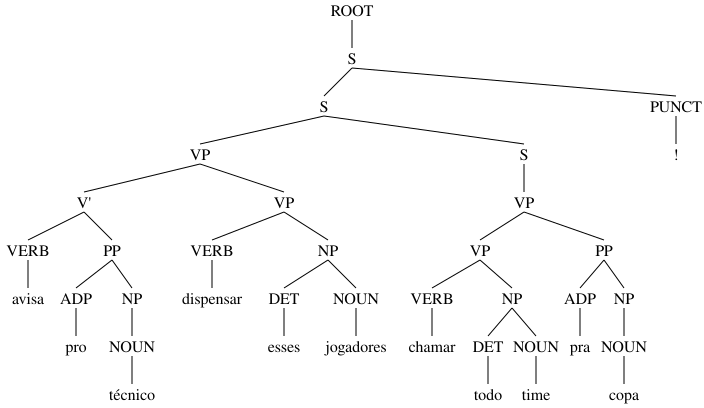


Árvore 2  [Cruzeiro]: 'elenco cruzeiro cheio acomodado. só pereira, romero, villalba, kaiki, kj cássio chamam responsabilidade si durante jogo. resto acomodado dentro campo.'


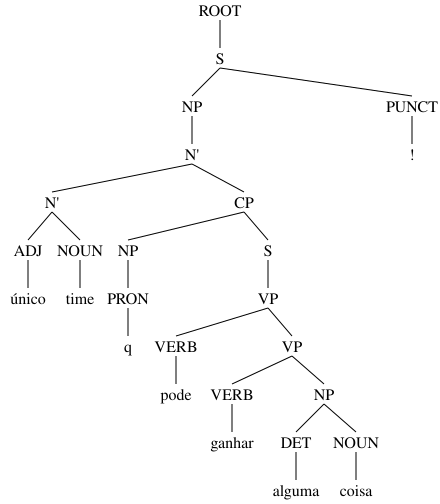


Árvore 3  [Santos]: 'vinícius jr: mas 1 jogo ruim seleção brasileira ( como costume) douglas santos: pior campo mim fora copa luiz henrique: melhor campo está copa mundo.'


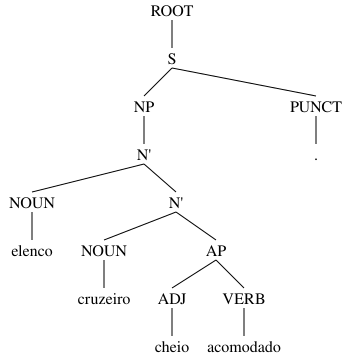


Árvore 4  [Corinthians]: 'volta protagonista! acabou depressão, quero todos sorrindo sendo feliz, bebeto voltou salvar corinthians.'


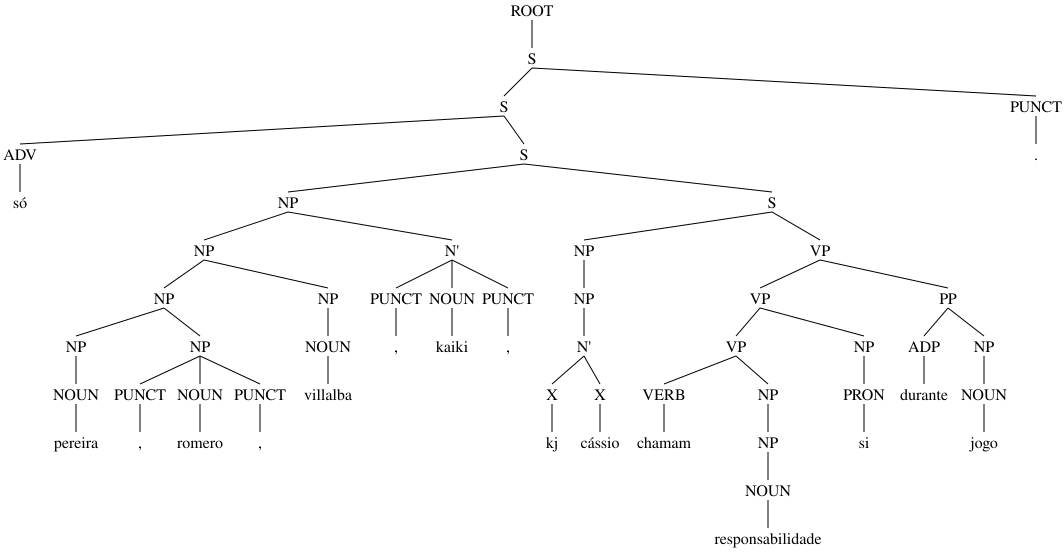


Árvore 5  [Palmeiras]: 'posso falar mesmo erro copa brasil pênalti eo caleri tava impedido eo palmeiras eliminado! sim pior erro história var pois as imagens sumiram!'


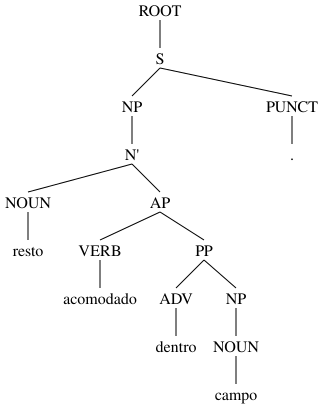

In [ ]:
# 2.2 - Visualização gráfica das árvores
print("--- 2.2 Visualização gráfica das árvores (nltk.Tree) ---")
for i, (frase, time, arv_str) in enumerate(zip(tweets_demo, times_demo, arvores_str)):
    print(f"\nÁrvore {i+1}  [{time}]: '{frase}'")
    try:
        arvore = Tree.fromstring(arv_str)
        display(arvore)
    except Exception as e:
        print(f"  >> Erro ao desenhar: {e}")

## Parte 3 — Extração SVO em todos os 1.299 tweets

Diferente do notebook original (que aplicava SVO em 6 frases inventadas), aqui rodamos a extração na **base inteira** e fazemos análise estatística do que sai.

Use `nlp.pipe()` com `disable=["ner"]` para acelerar — a extração SVO só precisa do parse de dependência, não do reconhecedor de entidades.

A pergunta que vamos responder:

- Quais são os **sujeitos**, **verbos** e **objetos** mais frequentes nos tweets?
- Que **verbos** aparecem mais quando se fala de cada **time**?


In [ ]:
# Roda spaCy em batch sobre todos os tweets já limpos
textos_full = df["Texto_limpo"].tolist()
print(f"Processando {len(textos_full)} tweets com spaCy...")

# Pega só os componentes que precisamos
docs = list(nlp_spacy.pipe(textos_full, batch_size=64, disable=["ner"]))
print("  OK\n")

# Extrai SVO de cada doc; guarda também o time de origem
todos_tripletos = []  # lista de dicts com sujeito/verbo/objeto/time/idx
for idx, (doc, time) in enumerate(zip(docs, df["Time"].tolist())):
    for s, v, o in extrair_svo_priorizado(doc):
        todos_tripletos.append({
            "tweet_idx": idx,
            "time": time,
            "sujeito": s.text.lower(),
            "sujeito_lemma": s.lemma_.lower(),
            "verbo": v.text.lower(),
            "verbo_lemma": v.lemma_.lower(),
            "objeto": o.text.lower(),
            "objeto_lemma": o.lemma_.lower(),
        })

triplos_df = pd.DataFrame(todos_tripletos)
print(f"Tripletos SVO extraídos: {len(triplos_df)}")
print(f"Tweets com pelo menos um SVO: {triplos_df['tweet_idx'].nunique()} de {len(df)}")
print(f"Cobertura: {100 * triplos_df['tweet_idx'].nunique() / len(df):.1f}%")
print()
triplos_df.head(10)

Processando 1299 tweets com spaCy...
  OK

Tripletos SVO extraídos: 489
Tweets com pelo menos um SVO: 431 de 1299
Cobertura: 33.2%



,tweet_idx,time,sujeito,sujeito_lemma,verbo,verbo_lemma,objeto,objeto_lemma
0,9,Flamengo,n,n,ganhar,ganhar,msm,msm
1,10,Flamengo,palmeiras,palmeira,ligar,ligar,sac,sac
2,18,Vasco,flamenguistas,flamenguista,fazendo,fazer,vídeos,vídeo
3,20,Grêmio,crime,crime,deixou,deixar,new,new
4,23,Grêmio,grêmio,grêmio,confirma,confirmar,promoção,promoção
5,24,Flamengo,comissão,comissão,confirmou,confirmar,nome,nome
6,27,São Paulo,fdp,fdp,vota,votar,bolsonaristas,bolsonarista
7,31,Palmeiras,palmeiras,palmeira,faz,fazer,muuuuuuito,muuuuuuito
8,33,Santos,kauê,kauê,comentou,comentar,cover,cover
9,33,Santos,brother,brother,ajudar,ajudar,pronúncia,pronúncia


### Top frequências (sujeitos, verbos, objetos)

Olhando os lemas (forma canônica), descobrimos rapidamente o vocabulário típico do "discurso de torcida":


In [ ]:
print("Top 15 SUJEITOS (lemma):")
print(triplos_df["sujeito_lemma"].value_counts().head(15).to_string())
print()
print("Top 15 VERBOS (lemma):")
print(triplos_df["verbo_lemma"].value_counts().head(15).to_string())
print()
print("Top 15 OBJETOS (lemma):")
print(triplos_df["objeto_lemma"].value_counts().head(15).to_string())

Top 15 SUJEITOS (lemma):
sujeito_lemma
flamengo    34
remo        13
vasco       12
quem        11
palmeira    10
cara        10
grêmio       9
neymar       9
jogador      7
santo        7
time         7
jogo         7
gente        7
douglas      7
você         6

Top 15 VERBOS (lemma):
verbo_lemma
jogar      26
fazer      23
ter        14
ganhar     12
dar        12
falar      10
tomar      10
saber      10
começar     9
ver         9
perder      9
deixar      8
ficar       7
passar      7
virar       7

Top 15 OBJETOS (lemma):
objeto_lemma
jogo        22
flamengo    15
gol         12
nada        11
seleção     10
eu           9
remo         8
santo        7
vasco        7
palmeira     6
jogador      6
time         5
ano          4
cruzeiro     4
campanha     4


### Análise por time: qual o "verbo característico" de cada torcida?

Aqui entramos em terreno **novo** (não está no notebook original). Para cada time, comparamos a distribuição dos verbos usados nos tweets daquela torcida com a distribuição global. Verbos com **alto desvio positivo** são os característicos daquela torcida.

Usamos uma heurística simples (`P(verbo | time) − P(verbo | global)`) ponderada por frequência mínima — ignoramos verbos muito raros que dão ruído.


In [ ]:
# Distribuição global de verbos
freq_global = triplos_df["verbo_lemma"].value_counts()
total_global = freq_global.sum()
prob_global = freq_global / total_global

print("Verbos característicos por time (top 5):")
print("-" * 80)

for time in df["Time"].unique():
    sub = triplos_df[triplos_df["time"] == time]
    if len(sub) < 5:
        print(f"\n[{time}]: amostra muito pequena ({len(sub)} SVOs), pulando.")
        continue

    freq_time = sub["verbo_lemma"].value_counts()
    total_time = freq_time.sum()
    prob_time = freq_time / total_time

    # Diferença prob_time - prob_global (alinhada por verbo)
    aligned = prob_time.subtract(prob_global, fill_value=0)
    # Filtra: o verbo precisa aparecer pelo menos 3 vezes para o time
    aligned = aligned[freq_time.reindex(aligned.index, fill_value=0) >= 3]
    top = aligned.sort_values(ascending=False).head(5)

    if len(top) == 0:
        print(f"\n[{time}]: nenhum verbo característico (verbos do time pouco frequentes).")
        continue

    print(f"\n[{time}] (n={len(sub)} SVOs):")
    for verbo, score in top.items():
        n_time = freq_time[verbo]
        n_global = freq_global[verbo]
        print(f"  {verbo:20s} (time: {n_time:3d}x  |  global: {n_global:3d}x  |  desvio: {score:+.4f})")

Verbos característicos por time (top 5):
--------------------------------------------------------------------------------

[Fluminense] (n=18 SVOs):
  ter                  (time:   3x  |  global:  14x  |  desvio: +0.1380)

[Flamengo] (n=158 SVOs):
  tomar                (time:   7x  |  global:  10x  |  desvio: +0.0239)
  vencer               (time:   3x  |  global:   3x  |  desvio: +0.0129)
  vir                  (time:   3x  |  global:   3x  |  desvio: +0.0129)
  colocar              (time:   3x  |  global:   4x  |  desvio: +0.0108)
  jogar                (time:  10x  |  global:  26x  |  desvio: +0.0101)

[Grêmio] (n=23 SVOs):
  começar              (time:   5x  |  global:   9x  |  desvio: +0.1990)

[Corinthians] (n=41 SVOs):
  ter                  (time:   4x  |  global:  14x  |  desvio: +0.0689)
  saber                (time:   3x  |  global:  10x  |  desvio: +0.0527)
  fazer                (time:   4x  |  global:  23x  |  desvio: +0.0505)

[Vasco] (n=49 SVOs):
  ganhar              

## Parte 4 — Grafo de Conhecimento a partir dos Tweets

Usamos os tripletos SVO extraídos pra construir um **grafo dirigido**: nós são entidades (sujeitos e objetos), arestas são relações (verbos).

Com 1.299 tweets, geramos centenas de tripletos — o grafo cru é uma teia ilegível. Aplicamos:

1. **Lematização** — agrupa "perdeu", "perde", "perdendo" em um nó só.
2. **Filtragem por frequência** — uma aresta entra no grafo só se a relação `(sujeito_lemma, verbo_lemma, objeto_lemma)` aparece **pelo menos `MIN_FREQ` vezes**.
3. **Limite de nós** — fica nos top-N nós mais conectados.

O resultado é um grafo legível dos **fatos repetidos** que dominam a conversa entre torcidas.


In [ ]:
# Conta tripletos lematizados
contagem_triplos = (
    triplos_df.groupby(["sujeito_lemma", "verbo_lemma", "objeto_lemma"])
              .size()
              .reset_index(name="freq")
              .sort_values("freq", ascending=False)
)
print(f"Tripletos únicos (lematizados): {len(contagem_triplos)}")
print("\nTop 15 tripletos mais frequentes:")
print(contagem_triplos.head(15).to_string(index=False))

Tripletos únicos (lematizados): 477

Top 15 tripletos mais frequentes:
sujeito_lemma verbo_lemma objeto_lemma  freq
         quem      roubar     palmeira     4
         remo       jogar     flamengo     3
         cara       tomar          gol     3
     torcedor    reclamar     dinheiro     2
        vasco       virar         jogo     2
     flamengo    destruir      seleção     2
     flamengo      sofrer         remo     2
     flamengo      entrar        campo     2
       piores         ver       camisa     1
           po       plmds        gente     1
      polícia   recuperar       camisa     1
      polícia   recuperar        carga     1
           pq     escalar          ele     1
           pq       poder    profissão     1
        prima       parar          meu     1


In [ ]:
# Constrói grafo filtrado por frequência
MIN_FREQ = 2  # aresta entra no grafo só se aparece >= MIN_FREQ vezes

G = nx.DiGraph()
for _, row in contagem_triplos.iterrows():
    if row["freq"] < MIN_FREQ:
        continue
    s = row["sujeito_lemma"].capitalize()
    v = row["verbo_lemma"]
    o = row["objeto_lemma"].capitalize()
    if s == o:
        continue  # ignora self-loops triviais
    if G.has_edge(s, o):
        # se já existe aresta, mantém o verbo mais frequente
        if row["freq"] > G[s][o].get("freq", 0):
            G[s][o]["label"] = v
            G[s][o]["freq"] = row["freq"]
    else:
        G.add_edge(s, o, label=v, freq=row["freq"])

print(f"Grafo: {G.number_of_nodes()} nós, {G.number_of_edges()} arestas (com MIN_FREQ={MIN_FREQ})")

# Se o grafo ficar enorme, ficamos com a maior componente conectada
if G.number_of_nodes() > 60:
    # Pega top 50 nós por grau total
    grau = dict(G.degree())
    top_nodes = sorted(grau, key=grau.get, reverse=True)[:50]
    G = G.subgraph(top_nodes).copy()
    print(f"  -> Reduzido para top 50 nós por grau: {G.number_of_nodes()} nós, {G.number_of_edges()} arestas")

Grafo: 12 nós, 8 arestas (com MIN_FREQ=2)


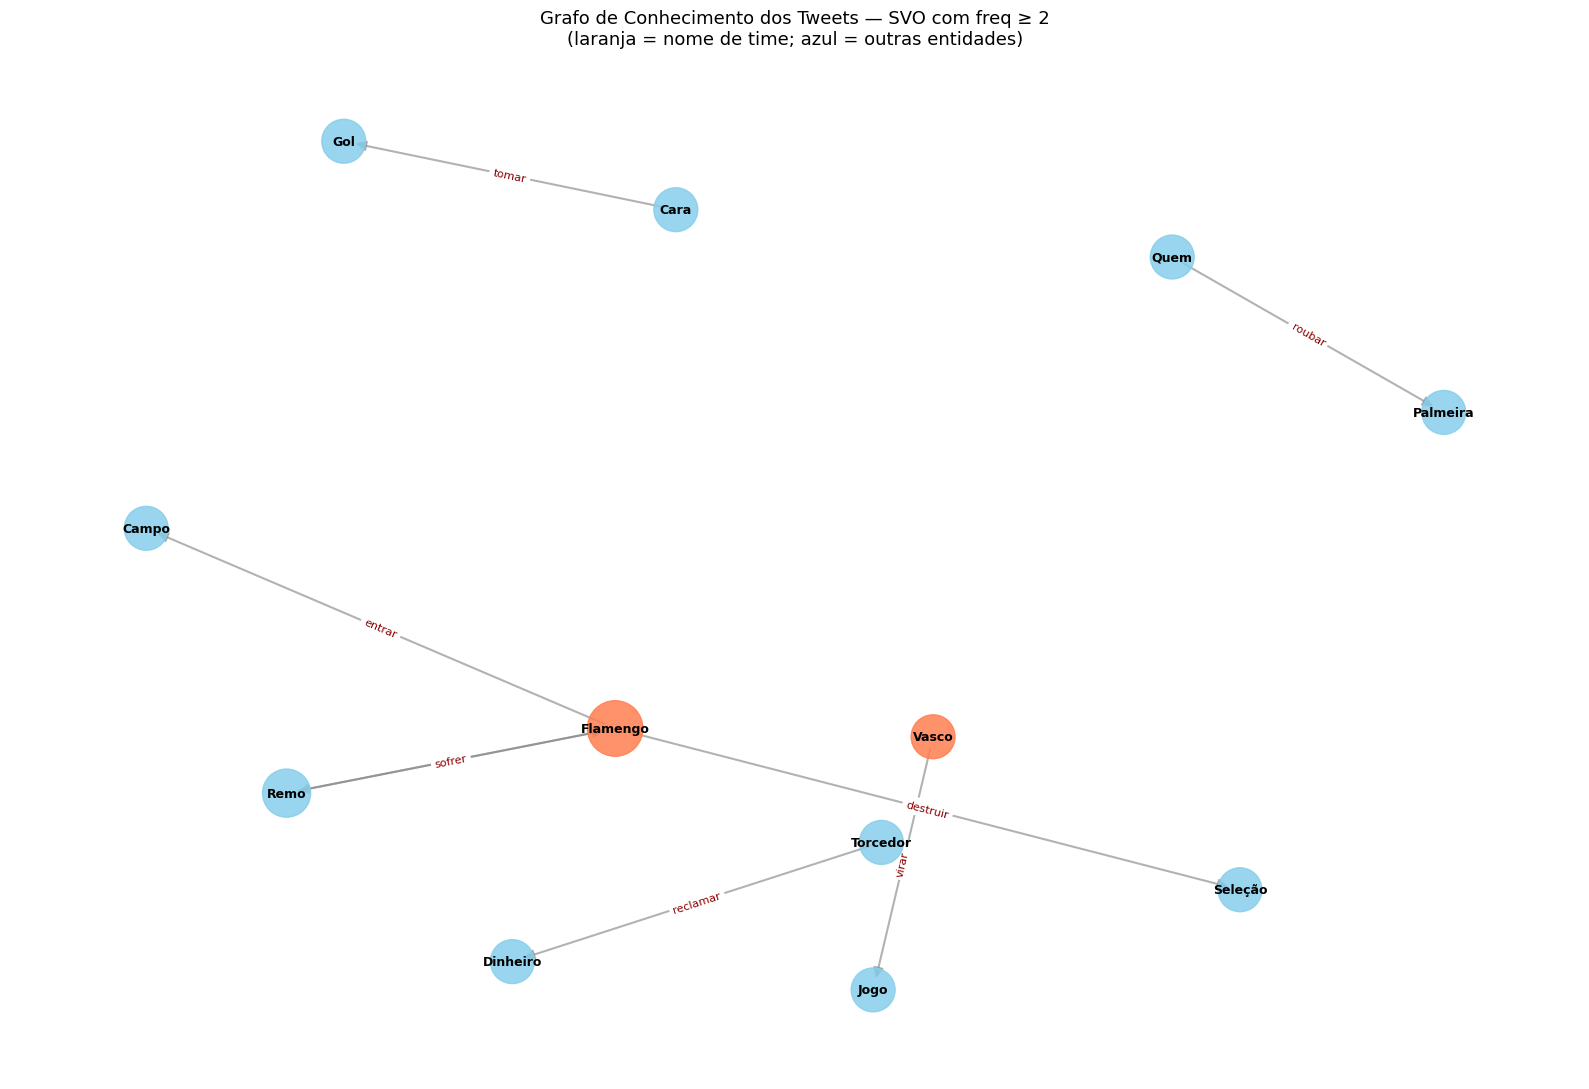

In [ ]:
# Coloração dos nós: se o nó é o nome de um time, destaca em cor distinta
times_lower = {t.lower() for t in df["Time"].unique()}
# também aliases comuns
aliases_time = {
    "fla", "mengão", "mengao", "rubro", "vasco", "vascão", "vascao",
    "santos", "peixe", "corinthians", "timão", "timao", "coringão", "coringao",
    "grêmio", "gremio", "tricolor", "palmeiras", "porco", "verdão", "verdao",
    "são", "spfc", "botafogo", "fogão", "fogao", "internacional", "inter", "colorado",
    "fluminense", "flu", "atletico", "galo", "cruzeiro", "raposa",
}
ehTime = lambda nome: nome.lower() in times_lower or nome.lower() in aliases_time

cores_nos = ["#ff7f50" if ehTime(n) else "#87ceeb" for n in G.nodes()]
tamanhos  = [800 + 200 * G.degree(n) for n in G.nodes()]

# Layout
plt.figure(figsize=(16, 11))
pos = nx.spring_layout(G, k=1.4, seed=SEED, iterations=100)

nx.draw_networkx_nodes(G, pos, node_size=tamanhos, node_color=cores_nos, alpha=0.85)
nx.draw_networkx_labels(G, pos, font_size=9, font_weight="bold")
nx.draw_networkx_edges(G, pos, width=1.5, alpha=0.6, edge_color="gray",
                       arrows=True, arrowsize=15)
edge_labels = {(s, t): d["label"] for s, t, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels,
                             font_color="darkred", font_size=8)

plt.title(f"Grafo de Conhecimento dos Tweets — SVO com freq ≥ {MIN_FREQ}\n"
          f"(laranja = nome de time; azul = outras entidades)", fontsize=13)
plt.axis("off")
plt.tight_layout()
plt.show()

### Sub-grafo por time: como cada torcida fala?

Para cada time com volume razoável de SVO, geramos um **sub-grafo só dos tripletos extraídos dos tweets daquele time**. Isso revela vocabulário, sujeitos preferidos e padrões discursivos específicos de cada torcida.


Sub-grafos para os 4 times com mais SVOs: ['Flamengo', 'Santos', 'Vasco', 'Corinthians']



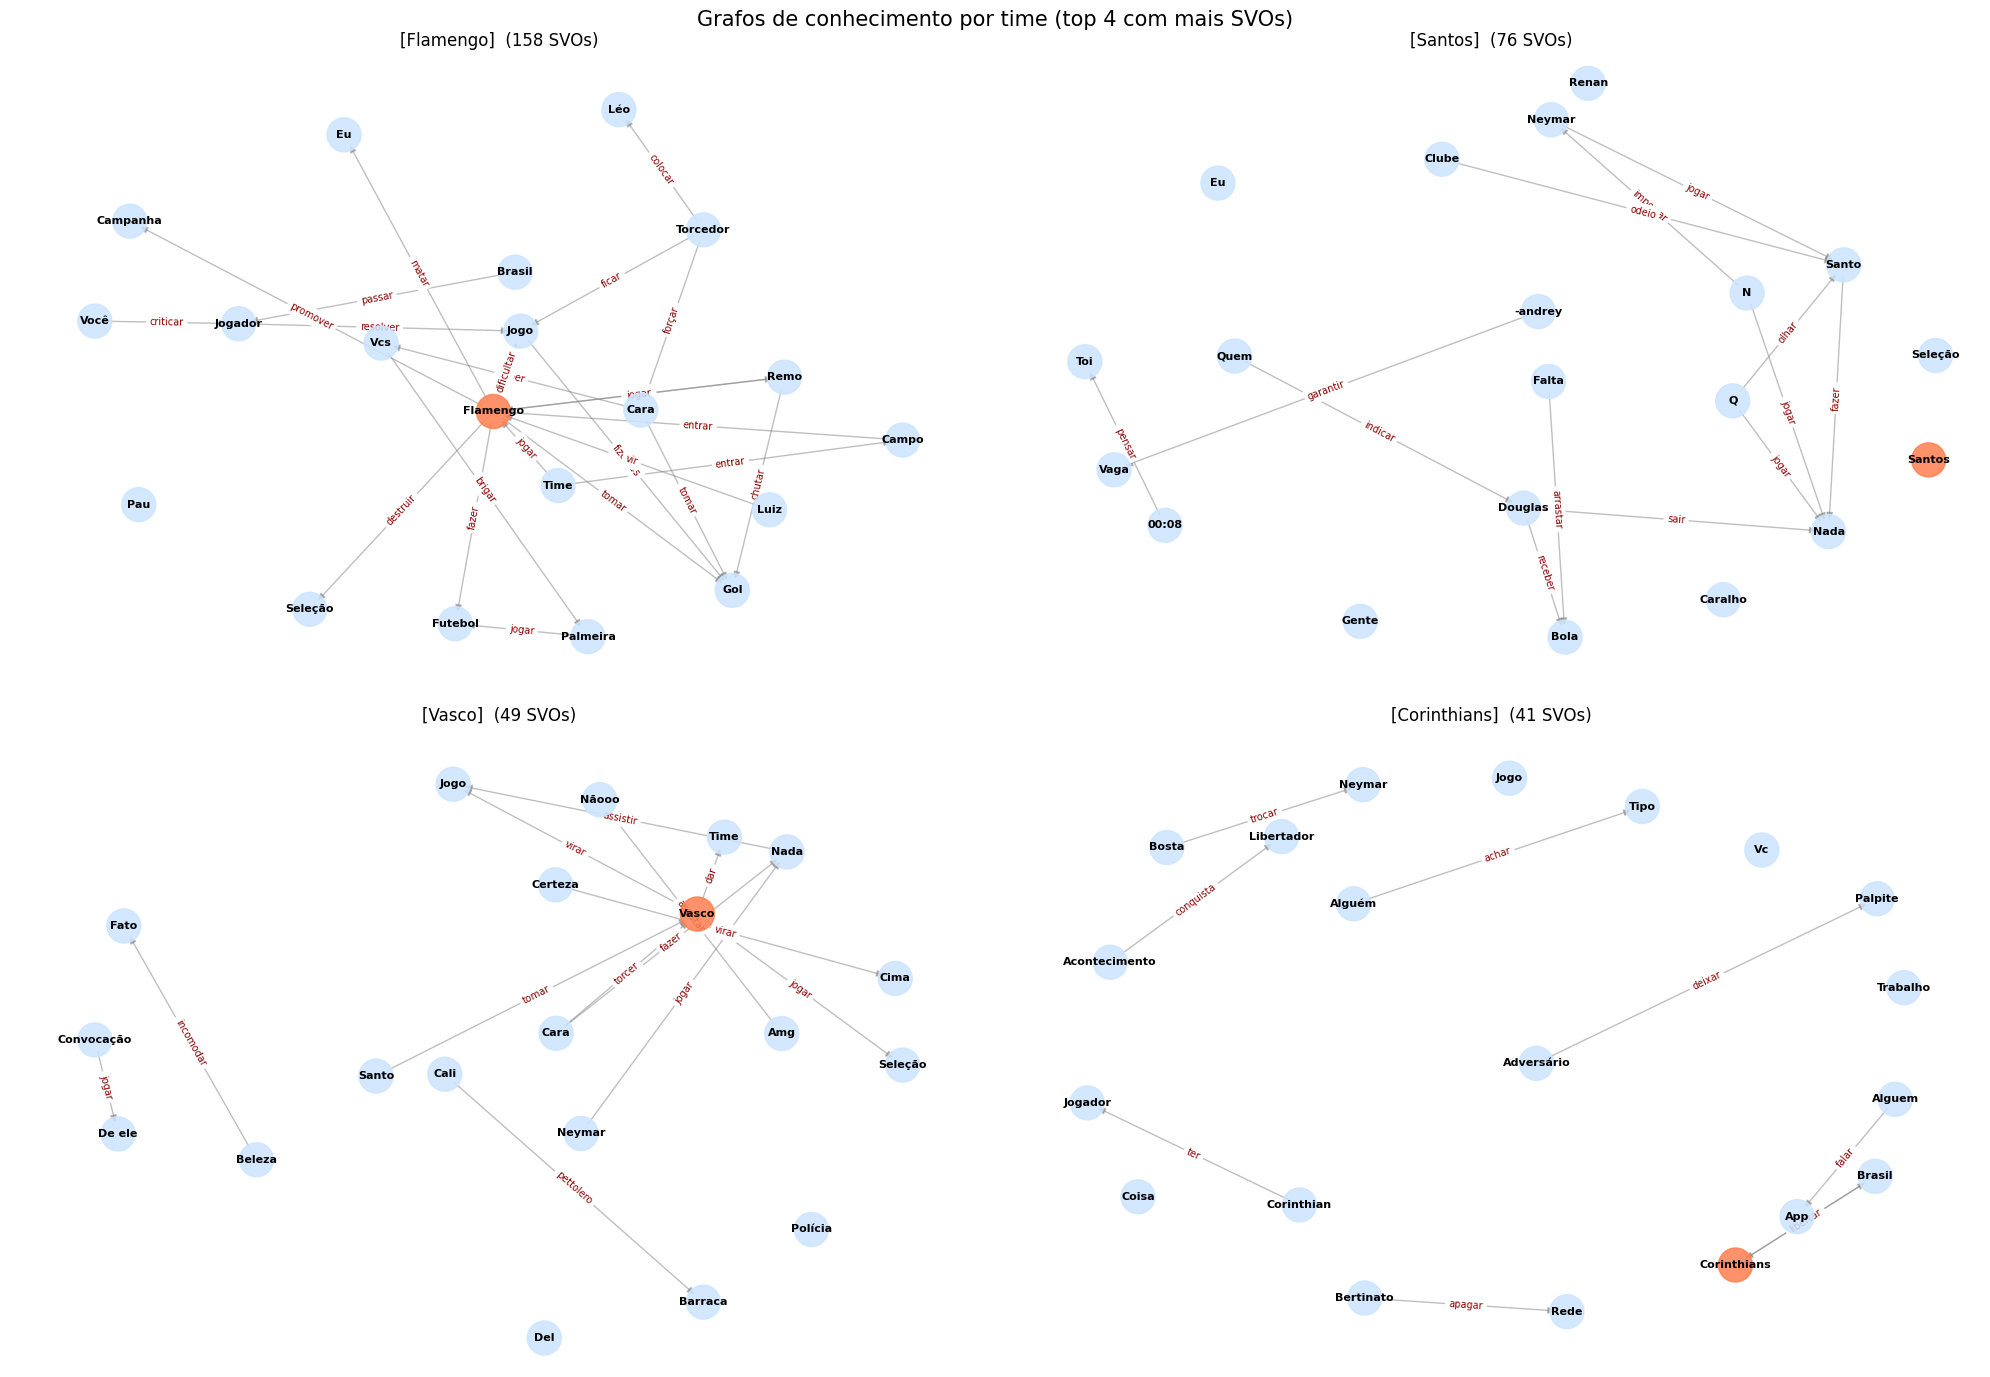

In [ ]:
# Gera sub-grafo por time, para os 4 times com mais SVOs
top_times = triplos_df["time"].value_counts().head(4).index.tolist()
print(f"Sub-grafos para os 4 times com mais SVOs: {top_times}\n")

fig, axes = plt.subplots(2, 2, figsize=(20, 14))
axes = axes.flatten()

for ax, time in zip(axes, top_times):
    sub = triplos_df[triplos_df["time"] == time]
    cont_sub = (sub.groupby(["sujeito_lemma", "verbo_lemma", "objeto_lemma"])
                   .size().reset_index(name="freq"))

    G_t = nx.DiGraph()
    for _, row in cont_sub.iterrows():
        # Para sub-grafo de time, MIN_FREQ=1 (já tá filtrado por time)
        s = row["sujeito_lemma"].capitalize()
        v = row["verbo_lemma"]
        o = row["objeto_lemma"].capitalize()
        if s == o:
            continue
        G_t.add_edge(s, o, label=v)

    if G_t.number_of_nodes() > 25:
        grau = dict(G_t.degree())
        top_nodes = sorted(grau, key=grau.get, reverse=True)[:20]
        G_t = G_t.subgraph(top_nodes).copy()

    cores = ["#ff7f50" if ehTime(n) else "#cce5ff" for n in G_t.nodes()]

    pos = nx.spring_layout(G_t, k=1.5, seed=SEED, iterations=80)
    nx.draw_networkx_nodes(G_t, pos, node_size=600, node_color=cores, alpha=0.85, ax=ax)
    nx.draw_networkx_labels(G_t, pos, font_size=8, font_weight="bold", ax=ax)
    nx.draw_networkx_edges(G_t, pos, width=1.0, alpha=0.5, edge_color="gray",
                           arrows=True, arrowsize=10, ax=ax)
    el = {(s, t): d["label"] for s, t, d in G_t.edges(data=True)}
    nx.draw_networkx_edge_labels(G_t, pos, edge_labels=el,
                                 font_color="darkred", font_size=7, ax=ax)
    ax.set_title(f"[{time}]  ({len(sub)} SVOs)", fontsize=12)
    ax.axis("off")

plt.suptitle("Grafos de conhecimento por time (top 4 com mais SVOs)", fontsize=15)
plt.tight_layout()
plt.show()

## Conclusão

Adaptamos o pipeline de **parsing** da aula original para um cenário real: 1.299 tweets brasileiros sobre 12 times de futebol. Vimos como **gramática de dependência** (relações binárias entre palavras) e **gramática de constituência** (agrupamentos hierárquicos em sintagmas) representam estrutura sintática a partir de ferramentas distintas (spaCy e Stanza).

#### O que olhar nos resultados

- **Cobertura SVO**: que % dos tweets gerou pelo menos um tripleto SVO? Tweets sem SVO geralmente são fragmentos, exclamações ou hashtag-spam.
- **Top sujeitos/verbos/objetos**: que palavras dominam o discurso de torcida? Verbos como *perder*, *ganhar*, *jogar*, *fazer*, *ser*?
- **Verbos característicos por time**: qual time tem mais o verbo *perder* na voz dos torcedores? Qual tem *ganhar*? Esse tipo de análise permite entender humor coletivo.
- **Grafo global**: que entidades-personagens (jogadores, técnicos, presidentes) estão mais conectadas?
- **Sub-grafos por time**: o vocabulário e os personagens variam dramaticamente?

#### Vantagens e Desvantagens

**Gramática de Dependência (spaCy)**
- ✅ Foca em relações binárias diretas entre palavras, ideal para extração SVO.
- ✅ Modelos rápidos e eficientes — rodamos em 1.299 tweets sem problema.
- ✅ Boa cobertura de português.
- ❌ Em texto informal de redes sociais, parses podem ficar erráticos (sem pontuação, gírias).

**Gramática de Constituência (Stanza)**
- ✅ Representa hierarquia completa (NP, VP, PP) — útil para análise estrutural detalhada.
- ✅ Facilita ver encaixes e ambiguidades de ligação (ex.: "postou uma foto com o celular").
- ❌ Mais lento — só rodamos em 5 tweets do demo. Inviável para 1.299.

**Extração SVO + Grafos**
- ✅ Convertem texto em **informação estruturada** — base para mineração, RAG, redes semânticas.
- ❌ Sensível à qualidade do parsing. Tweets ambíguos ou irônicos podem virar fatos errados.
- ❌ A semântica fica achatada: "Flamengo derrotou Vasco" e "Flamengo foi derrotado pelo Vasco" precisam de tratamento de **voz passiva** (que a função do notebook não trata explicitamente — exercício para o aluno!).

#### Próximos passos

- Estender `extrair_svo_priorizado` para tratar **voz passiva** (`nsubj:pass` + `obl:agent`).
- Usar **NER** (`spacy.ents`) em vez de tokens crus para nomes próprios — capturaria "Vitor Roque" como uma entidade só, em vez de quebrar em duas.
- Combinar parsing com os **embeddings** (Aulas 7 e 8): nós do grafo viram vetores; arestas viram contexto pra um modelo.
- Usar parsing como feature para **classificação** de tweets por sentimento, time ou tópico (slide 23 da aula menciona padrões SVO como features auxiliares para classificadores).
